# CASIA-WEBFACE | Face Verification

#### Christian Budhi S

In [1]:
!pip install -q insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 12.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 7.4 MB/s eta 0:00:00


In [2]:
import pickle, io, os, struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.spatial.distance import cosine
from sklearn.metrics import (
    roc_curve, roc_auc_score, average_precision_score,
    f1_score, accuracy_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from insightface.app import FaceAnalysis

In [3]:
REC_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.rec'
IDX_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.idx'
EVAL_BINS = {
    'lfw'      : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/lfw.bin',
    'cfp_fp'   : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/cfp_fp.bin',
    'agedb_30' : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/agedb_30.bin',
    'sllfw'    : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/sllfw.bin',
    'talfw'    : '/kaggle/input/datasets/debarghamitraroy/casia-webface/eval/talfw.bin',
}

OUT_DIR          = 'insightface_results'
MODELS           = ['buffalo_s', 'buffalo_l']
VALID_MIN_BYTES  = 100     # same filter as RecDataset
CAL_SAMPLE_SIZE  = 5000    # how many train pairs to use for calibration
_IR_FORMAT       = 'IfQQ'
_IR_SIZE         = struct.calcsize(_IR_FORMAT)
_IR_BUFFER       = 8       # magic + length

os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
import struct
import numpy as np
from collections import Counter


idx = {}
with open(IDX_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        idx[int(key)] = int(offset)

labels = []
with open(REC_PATH, 'rb') as f:
    for offset in idx.values():
        f.seek(offset)
        f.read(_IR_BUFFER)
        label = struct.unpack(_IR_FORMAT, f.read(_IR_SIZE))[1]
        labels.append(int(label))

counts      = Counter(labels)
sorted_counts = sorted(counts.values(), reverse=True)

low_thresh  = int(np.percentile(sorted_counts, 10))
high_thresh = int(np.percentile(sorted_counts, 80))

high_x = next(i for i, c in enumerate(sorted_counts) if c <= high_thresh)
low_x  = next(i for i, c in enumerate(sorted_counts) if c <= low_thresh)

train_ids = {pid for pid, cnt in counts.items() if low_thresh <= cnt <= high_thresh}
test_ids = {pid for pid, cnt in counts.items() if cnt <= low_thresh or cnt >= high_thresh}

print(f"Keep identities with photos between {high_thresh} and {low_thresh}")
print(f"Identities kept  : {sum(low_thresh <= c <= high_thresh for c in counts.values()):,}  [{sum(c if low_thresh <= c <= high_thresh else 0 for c in counts.values())}]")
print(f"Identities total : {len(counts):,} [{sum(c for c in counts.values())}]")

Keep identities with photos between 57 and 15
Identities kept  : 7,824  [214927]
Identities total : 10,572 [501196]


In [5]:
import random

raw_idx = {}
with open(IDX_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        key, offset = line.split('\t')
        raw_idx[int(key)] = int(offset)

# read headers only, filter invalid records, group by identity
from collections import defaultdict

label_to_offsets = defaultdict(list)
with open(REC_PATH, 'rb') as f:
    for offset in raw_idx.values():
        f.seek(offset)
        magic, length = struct.unpack('II', f.read(_IR_BUFFER))
        flag, label, _, _ = struct.unpack(_IR_FORMAT, f.read(_IR_SIZE))
        img_size = length - _IR_SIZE
        if img_size < VALID_MIN_BYTES:
            continue                        # skip malformed records
        pid = int(label)
        if pid in train_ids:               # only calibration on train_ids
            label_to_offsets[pid].append(offset)

all_pids = [pid for pid, offs in label_to_offsets.items() if len(offs) >= 2]
print(f"Valid identities for calibration : {len(all_pids):,}")
print(f"Total valid records              : {sum(len(v) for v in label_to_offsets.values()):,}")

Valid identities for calibration : 7,824
Total valid records              : 214,927


In [6]:
# ── Cell 3: Helper — decode image from offset ─────────────────────────────────
def read_img_from_offset(rec_file, offset):
    """Read and decode image bytes from .rec file at given offset.
    Returns PIL Image or None if invalid."""
    rec_file.seek(offset)
    magic, length = struct.unpack('II', rec_file.read(_IR_BUFFER))
    rec_file.read(_IR_SIZE)                       # skip header
    img_size  = length - _IR_SIZE
    if img_size < VALID_MIN_BYTES:
        return None
    img_bytes = rec_file.read(img_size)
    try:
        return Image.open(io.BytesIO(img_bytes)).convert('RGB')
    except Exception:
        return None


def get_embedding(recognizer, img_pil):
    """Get L2-normalized embedding from PIL Image."""
    img_np = np.array(img_pil)[:, :, ::-1]       # RGB → BGR
    feat   = recognizer.get_feat(img_np).flatten()
    return feat / np.linalg.norm(feat)


def find_optimal_threshold(probs, labels):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    return float(thresholds[np.argmax(tpr - fpr)])


def compute_metrics(probs, labels, threshold):
    probs  = np.array(probs).flatten()
    labels = np.array(labels).flatten()
    preds  = (probs >= threshold).astype(int)
    return {
        'threshold': threshold,
        'auc'      : roc_auc_score(labels, probs),
        'ap'       : average_precision_score(labels, probs),
        'f1'       : f1_score(labels, preds, average='macro'),
        'acc'      : accuracy_score(labels, preds),
    }


def save_plots(probs, labels, preds, name, model_name, out_dir):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    RocCurveDisplay.from_predictions(labels, probs, ax=axes[0], name=name)
    axes[0].set_title(f'{name} — ROC')
    PrecisionRecallDisplay.from_predictions(labels, probs, ax=axes[1], name=name)
    axes[1].set_title(f'{name} — PR')
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['diff', 'same'], ax=axes[2]
    )
    axes[2].set_title(f'{name} — confusion matrix')
    plt.suptitle(f'{model_name} / {name}', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'{model_name}_{name}.png'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [7]:
# ── Cell 4: Generate calibration pairs from train_ids ─────────────────────────
def generate_calibration_pairs(label_to_offsets, all_pids,
                                n_pairs=CAL_SAMPLE_SIZE, seed=42):
    """Generate balanced same/different pairs from train_ids."""
    rng    = random.Random(seed)
    pairs  = []   # list of (offset_a, offset_b, label)

    for i in range(n_pairs):
        same    = rng.random() > 0.5
        pid_a   = rng.choice(all_pids)
        off_a   = rng.choice(label_to_offsets[pid_a])

        if same and len(label_to_offsets[pid_a]) >= 2:
            off_b  = rng.choice([o for o in label_to_offsets[pid_a] if o != off_a])
            lbl    = 1
        else:
            pid_b  = rng.choice([p for p in all_pids if p != pid_a])
            off_b  = rng.choice(label_to_offsets[pid_b])
            lbl    = 0

        pairs.append((off_a, off_b, lbl))

    same_count = sum(1 for _, _, l in pairs if l == 1)
    print(f"Calibration pairs : {len(pairs):,}  "
          f"(same={same_count:,}  diff={len(pairs)-same_count:,})")
    return pairs

cal_pairs = generate_calibration_pairs(label_to_offsets, all_pids)

Calibration pairs : 5,000  (same=2,501  diff=2,499)



═══════════════════════════════════════════════════════
  buffalo_s
═══════════════════════════════════════════════════════
download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:03<00:00, 41391.30KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

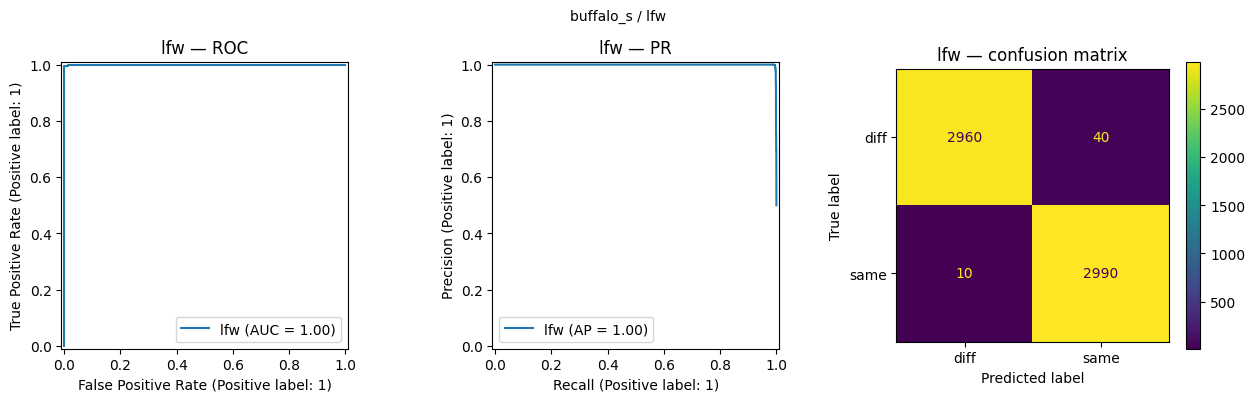


  ── cfp_fp
    AUC : 0.9738
    AP  : 0.9831
    F1  : 0.9584
    ACC : 0.9584


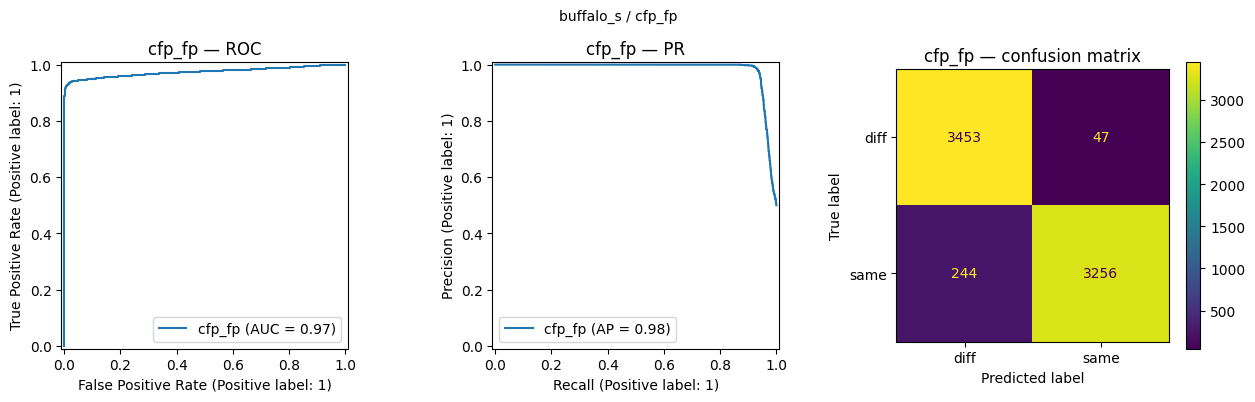


  ── agedb_30
    AUC : 0.9892
    AP  : 0.9921
    F1  : 0.9630
    ACC : 0.9630


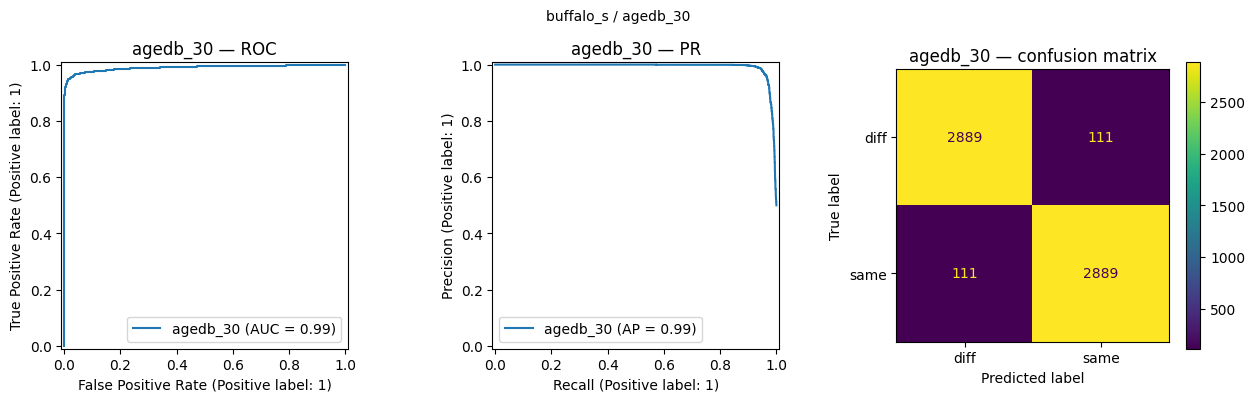


  ── sllfw
    AUC : 0.9976
    AP  : 0.9985
    F1  : 0.8985
    ACC : 0.8995


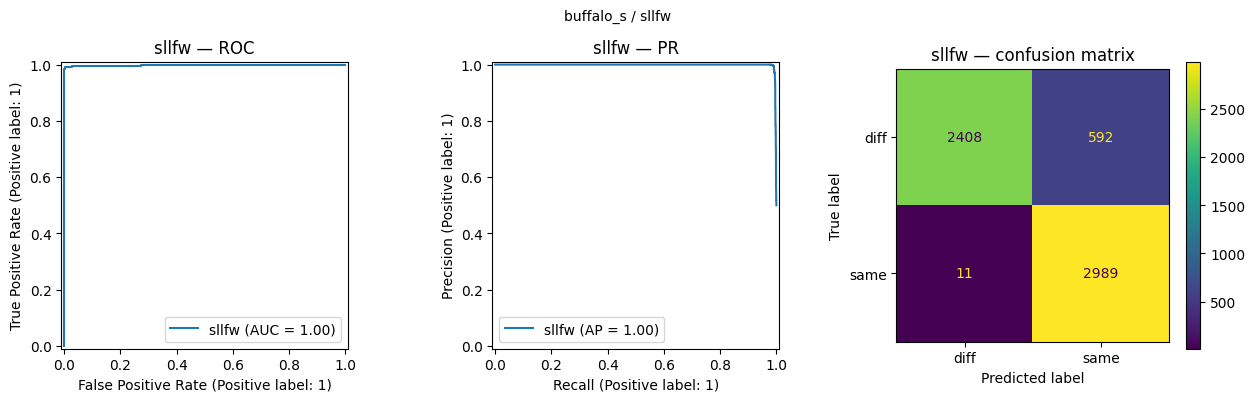


  ── talfw
    AUC : 0.5863
    AP  : 0.5856
    F1  : 0.5576
    ACC : 0.5632


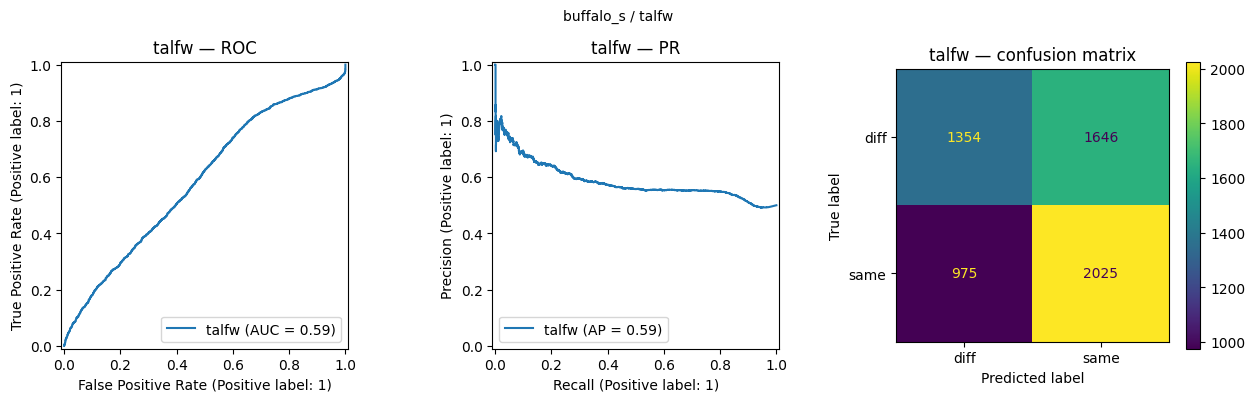


═══════════════════════════════════════════════════════
  buffalo_l
═══════════════════════════════════════════════════════
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 110376.13KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

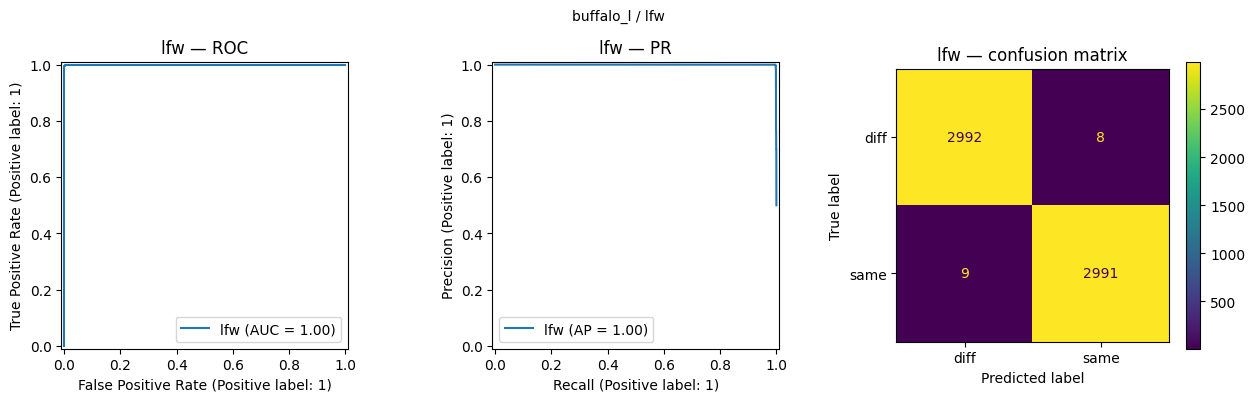


  ── cfp_fp
    AUC : 0.9800
    AP  : 0.9871
    F1  : 0.9743
    ACC : 0.9743


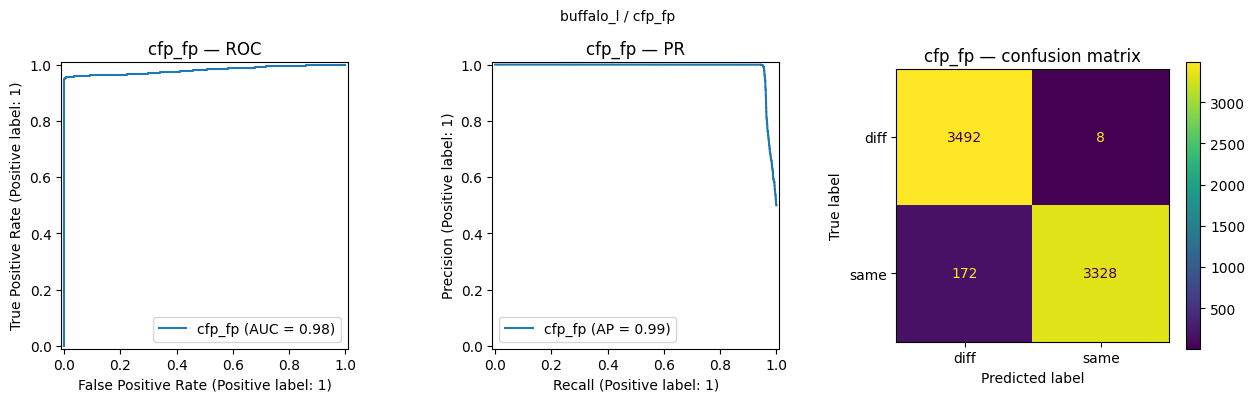


  ── agedb_30
    AUC : 0.9912
    AP  : 0.9943
    F1  : 0.9793
    ACC : 0.9793


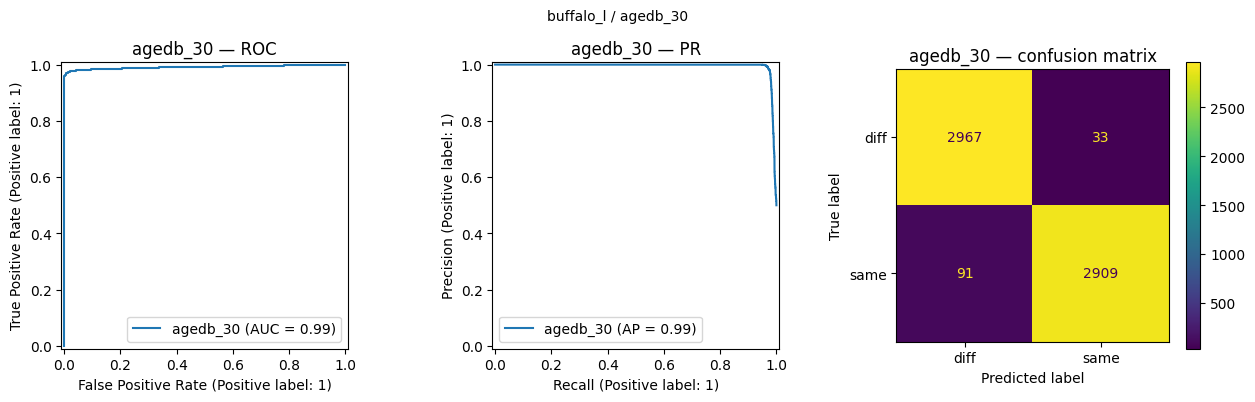


  ── sllfw
    AUC : 0.9985
    AP  : 0.9991
    F1  : 0.9737
    ACC : 0.9737


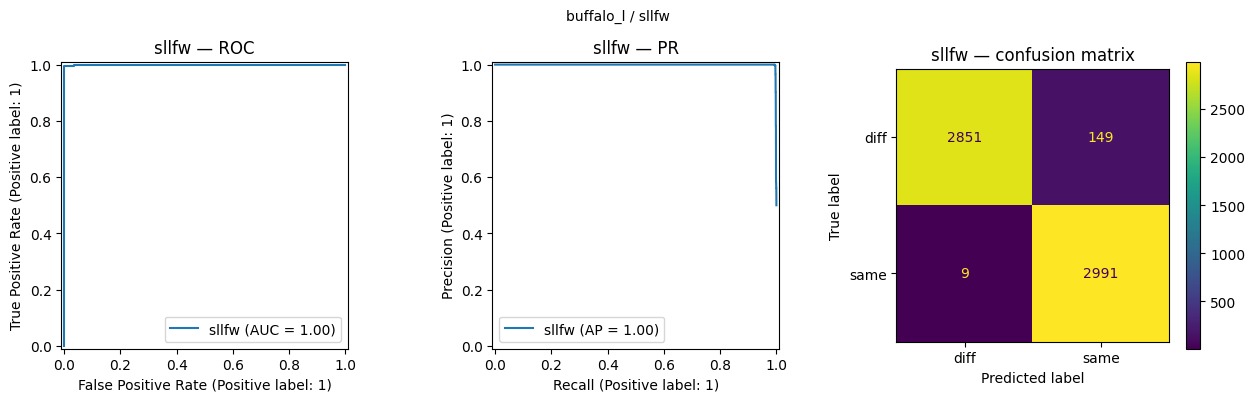


  ── talfw
    AUC : 0.7486
    AP  : 0.7588
    F1  : 0.6816
    ACC : 0.6827


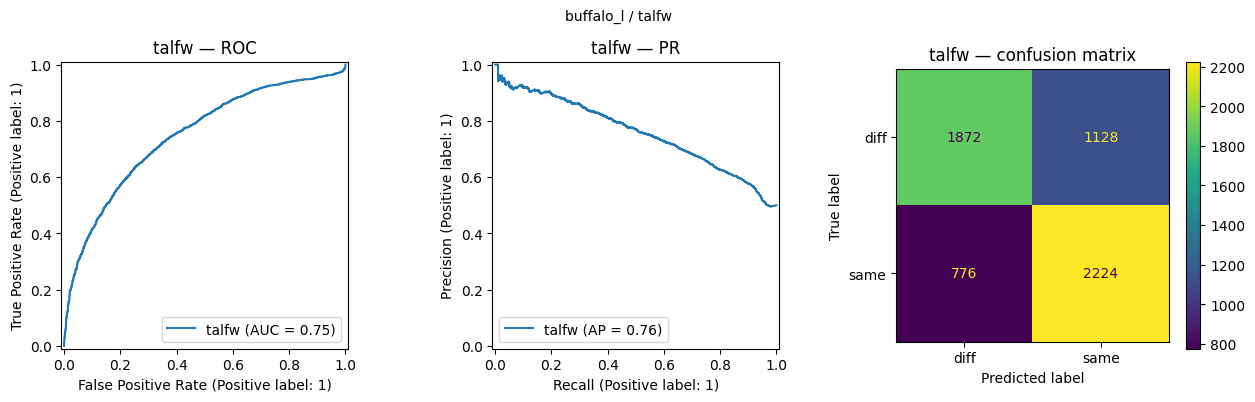

In [8]:
# ── Cell 5: Run evaluation ─────────────────────────────────────────────────────
all_results = []

with open(REC_PATH, 'rb') as rec_file:
    for model_name in MODELS:
        print(f"\n{'═'*55}")
        print(f"  {model_name}")
        print(f"{'═'*55}")

        app = FaceAnalysis(
            name      = model_name,
            providers = ['CUDAExecutionProvider', 'CPUExecutionProvider']
        )
        app.prepare(ctx_id=0, det_size=(112, 112))
        recognizer = app.models['recognition']

        model_dir = os.path.join(OUT_DIR, model_name)
        os.makedirs(model_dir, exist_ok=True)

        # ── Step 1: calibrate on train pairs ─────────────────────────
        print(f"\n[1/2] Calibrating threshold on {CAL_SAMPLE_SIZE} train pairs...")
        cal_sims, cal_labels = [], []
        skipped = 0

        for off_a, off_b, lbl in cal_pairs:
            img_a = read_img_from_offset(rec_file, off_a)
            img_b = read_img_from_offset(rec_file, off_b)
            if img_a is None or img_b is None:
                skipped += 1
                continue
            emb_a = get_embedding(recognizer, img_a)
            emb_b = get_embedding(recognizer, img_b)
            cal_sims.append(1 - cosine(emb_a, emb_b))
            cal_labels.append(lbl)

        cal_sims   = np.array(cal_sims)
        cal_labels = np.array(cal_labels)

        print(f"  Pairs used   : {len(cal_sims):,}  (skipped {skipped} invalid)")
        threshold = find_optimal_threshold(cal_sims, cal_labels)
        cal_auc   = roc_auc_score(cal_labels, cal_sims)
        print(f"  Cal AUC      : {cal_auc:.4f}")
        print(f"  Cal threshold: {threshold:.4f}")

        # save calibration info
        pd.DataFrame([{
            'model': model_name, 'threshold': threshold,
            'cal_auc': cal_auc, 'n_pairs': len(cal_sims)
        }]).to_csv(os.path.join(model_dir, 'calibration.csv'), index=False)

        # ── Step 2: evaluate on test benchmarks ──────────────────────
        print(f"\n[2/2] Evaluating on test benchmarks (threshold={threshold:.4f})...")

        for name, bin_path in EVAL_BINS.items():
            print(f"\n  ── {name}")
            with open(bin_path, 'rb') as f:
                bins, issame = pickle.load(f, encoding='bytes')
            labels = np.array(issame).astype(int)

            sims    = []
            skipped = 0
            for i in range(len(labels)):
                try:
                    img_a = Image.open(io.BytesIO(bins[i * 2])).convert('RGB')
                    img_b = Image.open(io.BytesIO(bins[i * 2 + 1])).convert('RGB')
                    if len(bins[i * 2]) < VALID_MIN_BYTES or \
                       len(bins[i * 2 + 1]) < VALID_MIN_BYTES:
                        skipped += 1
                        continue
                except Exception:
                    skipped += 1
                    continue
                emb_a = get_embedding(recognizer, img_a)
                emb_b = get_embedding(recognizer, img_b)
                sims.append(1 - cosine(emb_a, emb_b))

            if skipped > 0:
                print(f"    Skipped {skipped} invalid pairs")
                labels = labels[:len(sims)]   # align labels

            probs   = np.array(sims)
            metrics = compute_metrics(probs, labels, threshold)
            preds   = (probs >= threshold).astype(int)

            print(f"    AUC : {metrics['auc']:.4f}")
            print(f"    AP  : {metrics['ap']:.4f}")
            print(f"    F1  : {metrics['f1']:.4f}")
            print(f"    ACC : {metrics['acc']:.4f}")

            pd.DataFrame({
                'sim'      : probs,
                'label'    : labels,
                'pred'     : preds,
                'threshold': threshold,
            }).to_csv(os.path.join(model_dir, f'{name}_predictions.csv'), index=False)

            save_plots(probs, labels, preds, name, model_name, model_dir)
            all_results.append({'model': model_name, 'benchmark': name, **metrics})

In [9]:
# ── Cell 6: Summary ───────────────────────────────────────────────────────────
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)

for metric in ['auc', 'ap', 'f1', 'acc']:
    pivot = summary_df.pivot(index='benchmark', columns='model', values=metric)
    pivot = pivot.reindex(['lfw', 'cfp_fp', 'agedb_30', 'sllfw', 'talfw'])
    print(f"\n== {metric.upper()} ==")
    print(pivot.round(4).to_string())


== AUC ==
model      buffalo_l  buffalo_s
benchmark                      
lfw           0.9994     0.9993
cfp_fp        0.9800     0.9738
agedb_30      0.9912     0.9892
sllfw         0.9985     0.9976
talfw         0.7486     0.5863

== AP ==
model      buffalo_l  buffalo_s
benchmark                      
lfw           0.9996     0.9995
cfp_fp        0.9871     0.9831
agedb_30      0.9943     0.9921
sllfw         0.9991     0.9985
talfw         0.7588     0.5856

== F1 ==
model      buffalo_l  buffalo_s
benchmark                      
lfw           0.9972     0.9917
cfp_fp        0.9743     0.9584
agedb_30      0.9793     0.9630
sllfw         0.9737     0.8985
talfw         0.6816     0.5576

== ACC ==
model      buffalo_l  buffalo_s
benchmark                      
lfw           0.9972     0.9917
cfp_fp        0.9743     0.9584
agedb_30      0.9793     0.9630
sllfw         0.9737     0.8995
talfw         0.6827     0.5632
